In [ ]:
# Load dataset
import pandas as pd
train_data = pd.read_csv("/content/drive/MyDrive/train_data.txt",sep=':::',
                 names=['ID','TITLE','GENRE','DESCRIPTION'])
test_data=pd.read_csv("/content/drive/MyDrive/test_data.txt",sep=':::',
                      names=['ID','TITLE','DISCRIPTION'])

/tmp/ipykernel_2667/3029884715.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  train_data = pd.read_csv("/content/drive/MyDrive/train_data.txt",sep=':::',
/tmp/ipykernel_2667/3029884715.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test_data=pd.read_csv("/content/drive/MyDrive/test_data.txt",sep=':::',


In [ ]:
train_data.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [ ]:
test_data.head()

,ID,TITLE,DISCRIPTION
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),Before he was known internationally as a mart...


In [ ]:
print(train_data.info())
print(test_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  int64 
 1   TITLE        54214 non-null  object
 2   GENRE        54214 non-null  object
 3   DESCRIPTION  54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54200 entries, 0 to 54199
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54200 non-null  int64 
 1   TITLE        54200 non-null  object
 2   DISCRIPTION  54200 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [ ]:
print(train_data.describe())
print(test_data.describe())

                 ID
count  54214.000000
mean   27107.500000
std    15650.378084
min        1.000000
25%    13554.250000
50%    27107.500000
75%    40660.750000
max    54214.000000
                 ID
count  54200.000000
mean   27100.500000
std    15646.336632
min        1.000000
25%    13550.750000
50%    27100.500000
75%    40650.250000
max    54200.000000


In [ ]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())

ID             0
TITLE          0
GENRE          0
DESCRIPTION    0
dtype: int64
ID             0
TITLE          0
DISCRIPTION    0
dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=5000) # You can adjust max_features as needed

# Fit the vectorizer on the training data's DESCRIPTION column
tfidf.fit(train_data['DESCRIPTION'])

# Transform the test data's DISCRIPTION column (corrected column name)
x_text = tfidf.transform(test_data['DISCRIPTION'])


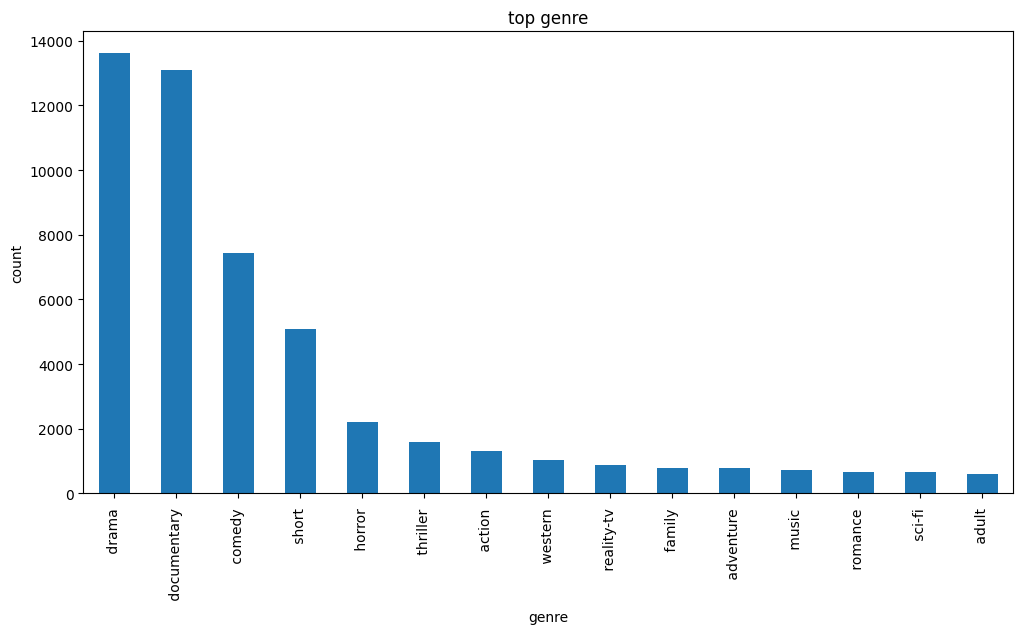

In [ ]:
#Genre Distribution visualization
import numpy as no
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
train_data['GENRE'].value_counts().head(15).plot(kind='bar')
plt.title("top genre")
plt.xlabel("genre")
plt.ylabel("count")
plt.show()

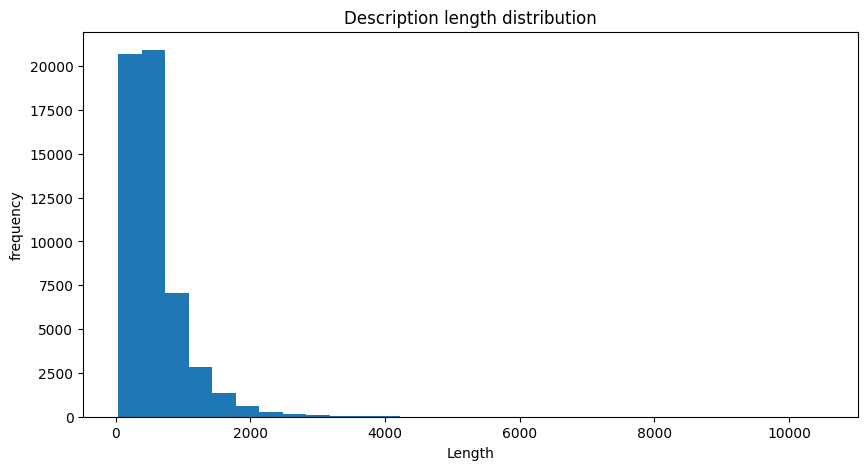

In [ ]:
#Description length analysis
train_data['desc_length']=train_data['DESCRIPTION'].str.len()
plt.figure(figsize=(10,5))
plt.hist(train_data['desc_length'],bins=30)
plt.title("Description length distribution")
plt.xlabel("Length")
plt.ylabel("frequency")
plt.show()

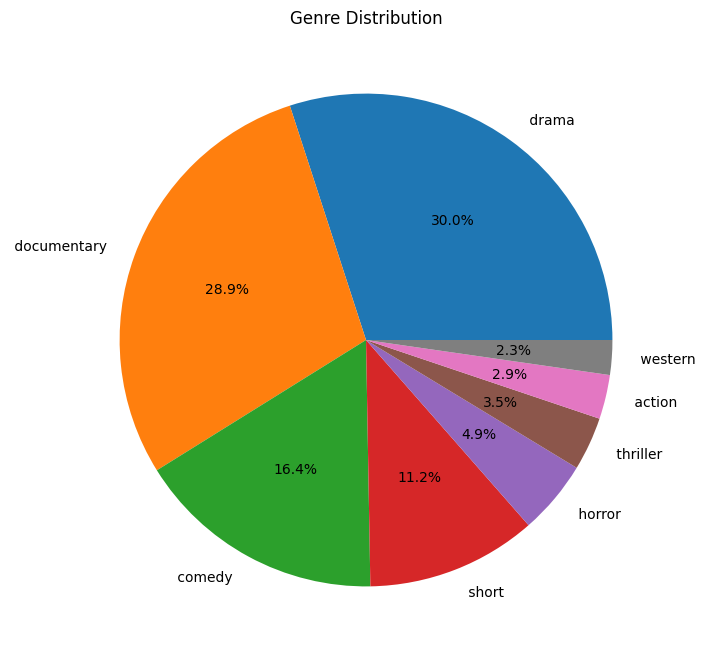

In [ ]:
#genre percentage pie chart
train_data['GENRE'].value_counts().head(8).plot(
    kind='pie',autopct='%1.1f%%',
     figsize=(8,8)
     )
plt.title("Genre Distribution")
plt.ylabel('')
plt.show()

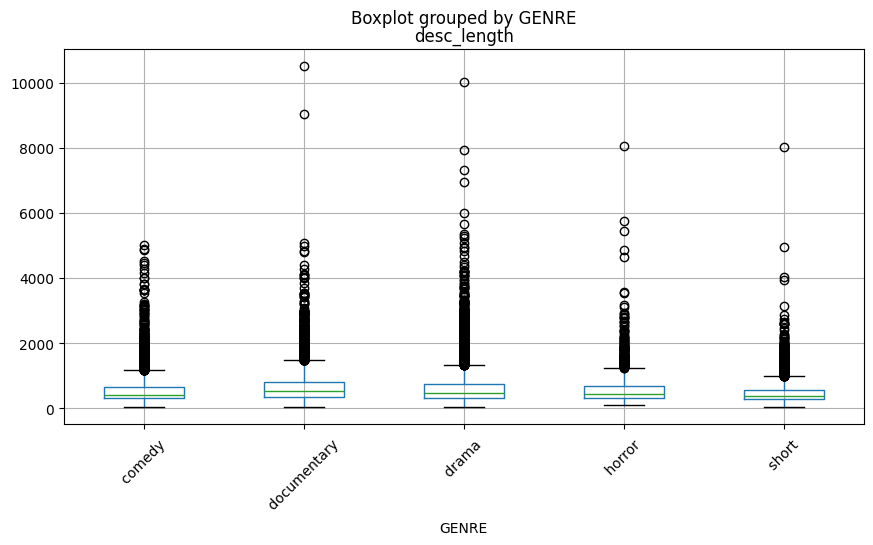

In [ ]:
#Description length by Genre
import matplotlib.pyplot as plt
top_genre = train_data['GENRE'].value_counts().head(5).index
data = train_data[train_data['GENRE'].isin(top_genre)]
data.boxplot(column='desc_length', by='GENRE', figsize=(10,5))
plt.xticks(rotation=45)
plt.show()

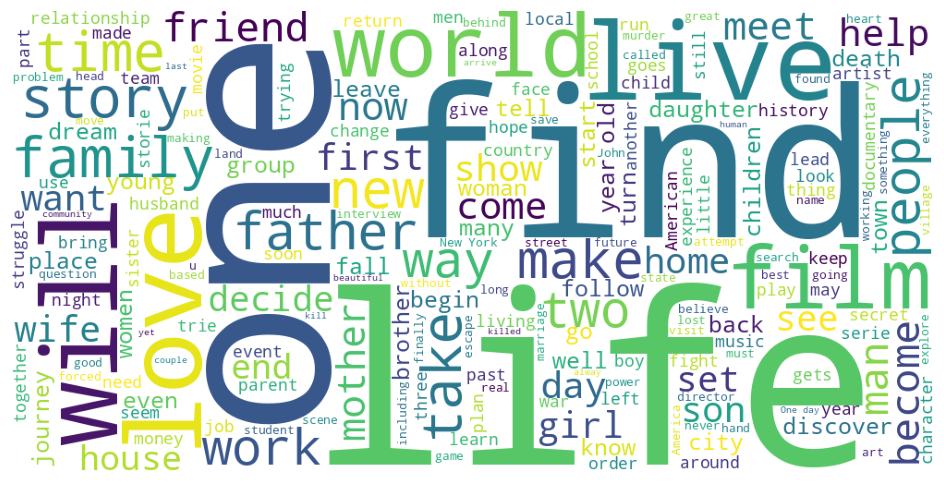

In [ ]:
#top word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text="".join(train_data['DESCRIPTION'])
wordcloud=WordCloud(width=1000, height=500,
                    background_color='white'). generate (text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

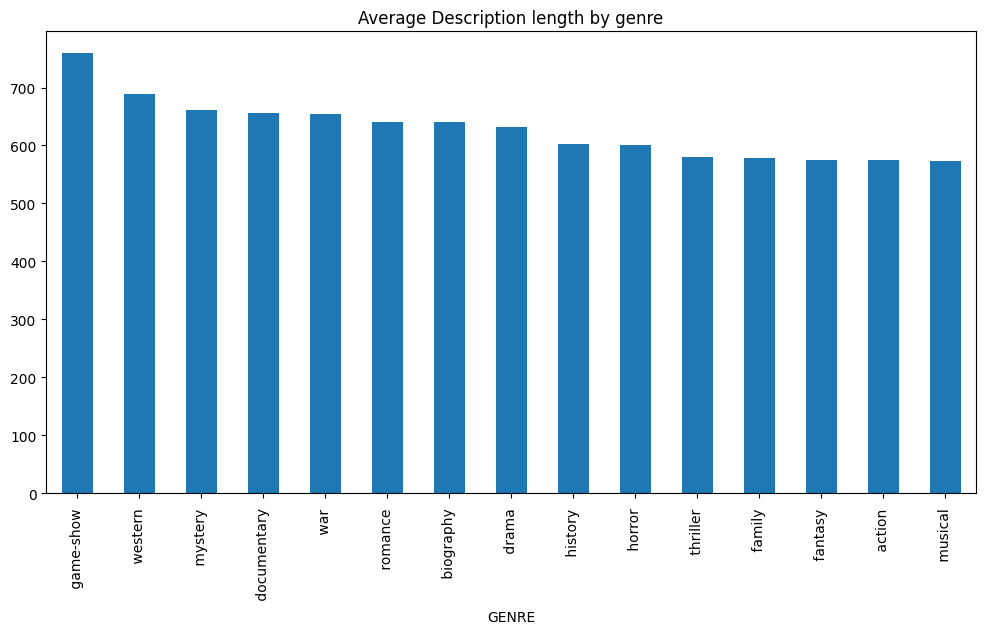

In [ ]:
#Average Description length per genre
avg_len = train_data.groupby('GENRE')['desc_length'].mean()
avg_len.sort_values(ascending=False).head(15).plot(kind='bar',figsize=(12,6))
plt.title("Average Description length by genre")
plt.show()

In [ ]:
#genre frequency table
genre_table = train_data['GENRE'].value_counts()
print(genre_table)

GENRE
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult             590
crime             505
animation         498
sport             432
talk-show         391
fantasy           323
mystery           319
musical           277
biography         265
history           243
game-show         194
news              181
war               132
Name: count, dtype: int64


In [ ]:
#text preprocessing
train_data['description']= train_data['DESCRIPTION'].fillna("")

In [ ]:
#feature extration tf idf
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english',max_features=5000)
x = tfidf.fit_transform(train_data['DESCRIPTION'])
y = train_data['GENRE']

In [ ]:
#spli dataset
from sklearn.model_selection import train_test_split
x_train,x_valid,y_train,y_valid=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#validation accuracy
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Define and train a simple model (e.g., Logistic Regression)
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(x_train, y_train)

y_pred=model.predict(x_valid)
accuracy=accuracy_score(y_valid,y_pred)
print("Accuracy", accuracy)

Accuracy 0.5799133081250576


In [ ]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_valid, y_pred))

               precision    recall  f1-score   support

      action        0.51      0.25      0.34       263
       adult        0.75      0.21      0.33       112
   adventure        0.42      0.14      0.21       139
   animation        0.60      0.09      0.15       104
   biography        0.00      0.00      0.00        61
      comedy        0.51      0.59      0.55      1443
       crime        0.29      0.02      0.04       107
 documentary        0.66      0.85      0.74      2659
       drama        0.54      0.78      0.64      2697
      family        0.39      0.07      0.12       150
     fantasy        0.00      0.00      0.00        74
   game-show        0.94      0.42      0.59        40
     history        0.00      0.00      0.00        45
      horror        0.64      0.56      0.60       431
       music        0.62      0.47      0.54       144
     musical        1.00      0.02      0.04        50
     mystery        0.00      0.00      0.00        56
        n

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#predict genres
x_test=tfidf.transform(test_data['DISCRIPTION'])
prediction= model.predict(x_test)
print(prediction[:20])

[' short ' ' drama ' ' documentary ' ' drama ' ' drama ' ' drama '
 ' drama ' ' comedy ' ' documentary ' ' drama ' ' drama ' ' drama '
 ' drama ' ' documentary ' ' short ' ' sport ' ' comedy ' ' western '
 ' documentary ' ' drama ']


In [ ]:
#test data solutions accuracy
solution=pd.read_csv("/content/drive/MyDrive/test_data_solution.txt",sep=':::',
                     names=['ID','TITLE','GENRE','DESCRIPTION'])
from sklearn.metrics import accuracy_score
accuracy= accuracy_score(solution['GENRE'],prediction)
print("Accuracy", accuracy)

/tmp/ipykernel_2667/1326454747.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  solution=pd.read_csv("/content/drive/MyDrive/test_data_solution.txt",sep=':::',


Accuracy 0.5781918819188192


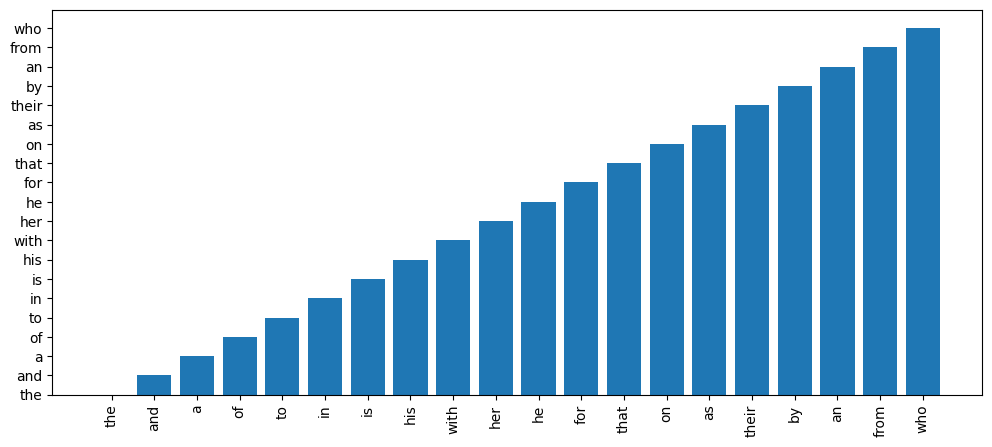

In [ ]:
#top 20 most common words
from collections import Counter
words ="".join(train_data['DESCRIPTION']).lower().split()
common=Counter(words).most_common(20)
words=[x[0]for x in common]
counts=[x[0]for x in common]
plt.figure(figsize=(12,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.show()

In [ ]:
import pandas as pd

#save predictions
Submission=pd.DataFrame({'id':test_data['ID'],"predicted_genre": prediction})
Submission.to_csv("genre_predictions.csv",index=False)
print("saved successfully")

saved successfully


In [ ]:
import pickle
pickle.dump(model,open("genre_model.pkl","wb"))
pickle.dump(tfidf,open("tfidf.pkl","wb"))